# Day 3 — Model Comparison with MLflow Tracking

Train and compare three fault-detection approaches on the UCI SECOM dataset:  
1. **Isolation Forest** — unsupervised anomaly detection baseline  
2. **Random Forest classifier** — supervised baseline with class weighting  
3. **LSTM Autoencoder** (PyTorch) — deep learning, reconstruction-error anomaly scoring  

All experiments are logged to MLflow for reproducible comparison.

## 1. Setup & imports

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import mlflow
import mlflow.sklearn
import mlflow.pytorch
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest, RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    precision_recall_curve, auc, f1_score, precision_score,
    recall_score, roc_curve
)

import warnings
warnings.filterwarnings('ignore')

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)

print('Setup complete.')

Setup complete.


## 2. Load processed data

In [ ]:
X = pd.read_csv('../data/processed/X_clean.csv')
y = pd.read_csv('../data/processed/y.csv').values.ravel()

print(f'Features: {X.shape[1]}')
print(f'Samples:  {X.shape[0]}')
print(f'Fail rate: {y.mean():.1%} ({y.sum():.0f} / {len(y)})')

Features: 446
Samples:  1567
Fail rate: 6.6% (104 / 1567)


## 3. Train/test split & scaling

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

print(f'Train: {X_train_sc.shape[0]} samples ({y_train.sum():.0f} fail)')
print(f'Test:  {X_test_sc.shape[0]} samples ({y_test.sum():.0f} fail)')

Train: 1253 samples (83 fail)
Test:  314 samples (21 fail)


## 4. MLflow experiment setup

We use a local file-based tracking URI. Each model gets its own run.

In [ ]:
mlflow.set_tracking_uri('../mlruns')
EXPERIMENT_NAME = 'secom-fault-detection'
mlflow.set_experiment(EXPERIMENT_NAME)

print(f'MLflow experiment: {EXPERIMENT_NAME}')
print(f'Tracking URI: {mlflow.get_tracking_uri()}')

MLflow experiment: secom-fault-detection
Tracking URI: mlruns


### Evaluation helper

In [21]:
def evaluate_model(y_true, y_pred, y_scores, model_name):
    """Compute metrics and build a confusion matrix figure."""
    roc = roc_auc_score(y_true, y_scores)
    pr_prec, pr_rec, _ = precision_recall_curve(y_true, y_scores)
    pr = auc(pr_rec, pr_prec)
    
    metrics = {
        'roc_auc': roc,
        'pr_auc': pr,
        'fail_recall': recall_score(y_true, y_pred),
        'fail_precision': precision_score(y_true, y_pred, zero_division=0),
        'fail_f1': f1_score(y_true, y_pred, zero_division=0),
    }
    
    print(f'\n--- {model_name} ---')
    print(f'ROC-AUC: {roc:.4f}  |  PR-AUC: {pr:.4f}')
    print(classification_report(y_true, y_pred, target_names=['Pass', 'Fail']))
    
    # Confusion matrix figure (for MLflow artifact logging)
    cm = confusion_matrix(y_true, y_pred)
    fig_cm, ax_cm = plt.subplots(figsize=(4, 3.5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Pass', 'Fail'], yticklabels=['Pass', 'Fail'], ax=ax_cm)
    ax_cm.set_xlabel('Predicted')
    ax_cm.set_ylabel('Actual')
    ax_cm.set_title(f'{model_name} — Confusion Matrix')
    fig_cm.tight_layout()
    
    return metrics, pr_prec, pr_rec, fig_cm

## 5. Model 1 — Isolation Forest

Unsupervised anomaly detection. We set `contamination` to the known fail rate  
so the model expects ~6.6% anomalies. No labels are used during training.


--- Isolation Forest ---
ROC-AUC: 0.5732  |  PR-AUC: 0.1529
              precision    recall  f1-score   support

        Pass       0.94      0.95      0.94       293
        Fail       0.20      0.19      0.20        21

    accuracy                           0.89       314
   macro avg       0.57      0.57      0.57       314
weighted avg       0.89      0.89      0.89       314



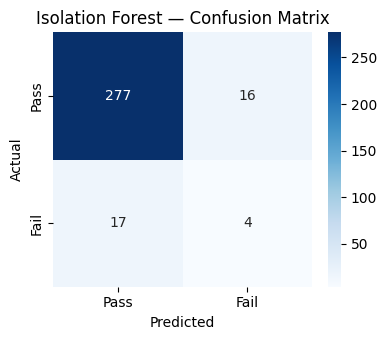

2026/03/30 10:52:19 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/30 10:52:19 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html



MLflow run ID: 38329419543d47259e78d3fa4cfc5566


In [22]:
CONTAMINATION = y.mean()  # ~0.066

with mlflow.start_run(run_name='isolation_forest'):
    # ── Params ──
    iso_params = {
        'n_estimators': 200,
        'contamination': round(CONTAMINATION, 4),
        'random_state': RANDOM_STATE,
        'model_type': 'unsupervised',
    }
    mlflow.log_params(iso_params)
    
    # ── Train ──
    iso = IsolationForest(
        n_estimators=iso_params['n_estimators'],
        contamination=iso_params['contamination'],
        random_state=RANDOM_STATE,
        n_jobs=-1
    )
    iso.fit(X_train_sc)
    
    # ── Predict ──
    iso_preds = (iso.predict(X_test_sc) == -1).astype(int)
    iso_scores = -iso.decision_function(X_test_sc)
    
    # ── Evaluate ──
    iso_metrics, iso_pr_prec, iso_pr_rec, iso_cm_fig = evaluate_model(
        y_test, iso_preds, iso_scores, 'Isolation Forest'
    )
    mlflow.log_metrics(iso_metrics)
    mlflow.log_figure(iso_cm_fig, 'confusion_matrix.png')
    plt.show()
    
    # ── Log model ──
    mlflow.sklearn.log_model(iso, 'model')
    
    iso_run_id = mlflow.active_run().info.run_id
    print(f'\nMLflow run ID: {iso_run_id}')

## 6. Model 2 — Random Forest (class-weighted)

Supervised classifier with `class_weight='balanced'` to address 14:1 imbalance.  
We also tune the decision threshold to maximize Fail-class F1.

Optimal threshold: 0.20 (Fail F1 = 0.3415)

--- Random Forest (tuned) ---
ROC-AUC: 0.7928  |  PR-AUC: 0.2084
              precision    recall  f1-score   support

        Pass       0.95      0.96      0.95       293
        Fail       0.35      0.33      0.34        21

    accuracy                           0.91       314
   macro avg       0.65      0.64      0.65       314
weighted avg       0.91      0.91      0.91       314



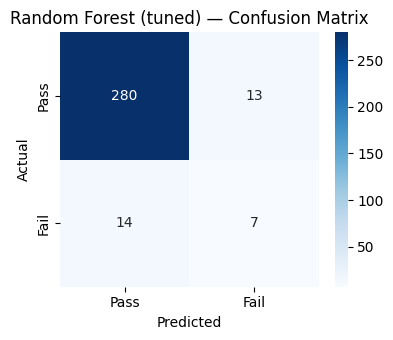

2026/03/30 10:52:23 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/30 10:52:23 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html



MLflow run ID: 6357a161289c402eac8549b0bafda09a


In [23]:
with mlflow.start_run(run_name='random_forest'):
    # ── Params ──
    rf_params = {
        'n_estimators': 300,
        'max_depth': 15,
        'min_samples_leaf': 5,
        'class_weight': 'balanced',
        'random_state': RANDOM_STATE,
        'model_type': 'supervised',
    }
    mlflow.log_params(rf_params)
    
    # ── Train ──
    rf = RandomForestClassifier(
        n_estimators=rf_params['n_estimators'],
        max_depth=rf_params['max_depth'],
        min_samples_leaf=rf_params['min_samples_leaf'],
        class_weight=rf_params['class_weight'],
        random_state=RANDOM_STATE,
        n_jobs=-1
    )
    rf.fit(X_train_sc, y_train)
    
    # ── Predict (default threshold) ──
    rf_proba = rf.predict_proba(X_test_sc)[:, 1]
    
    # ── Threshold tuning: maximize Fail F1 ──
    best_f1, best_threshold = 0, 0.5
    for t in np.arange(0.05, 0.55, 0.01):
        preds_t = (rf_proba >= t).astype(int)
        if preds_t.sum() == 0:
            continue
        f1_t = f1_score(y_test, preds_t)
        if f1_t > best_f1:
            best_f1, best_threshold = f1_t, t
    
    print(f'Optimal threshold: {best_threshold:.2f} (Fail F1 = {best_f1:.4f})')
    mlflow.log_param('optimal_threshold', round(best_threshold, 2))
    
    # ── Evaluate at tuned threshold ──
    rf_preds = (rf_proba >= best_threshold).astype(int)
    rf_metrics, rf_pr_prec, rf_pr_rec, rf_cm_fig = evaluate_model(
        y_test, rf_preds, rf_proba, 'Random Forest (tuned)'
    )
    mlflow.log_metrics(rf_metrics)
    mlflow.log_figure(rf_cm_fig, 'confusion_matrix.png')
    plt.show()
    
    # ── Feature importances ──
    importances = pd.Series(rf.feature_importances_, index=X.columns)
    top_features = importances.nlargest(15)
    mlflow.log_dict(
        {'top_features': top_features.to_dict()},
        'feature_importances.json'
    )
    
    # ── Log model ──
    mlflow.sklearn.log_model(rf, 'model')
    
    rf_run_id = mlflow.active_run().info.run_id
    print(f'\nMLflow run ID: {rf_run_id}')

### Top 15 Random Forest feature importances

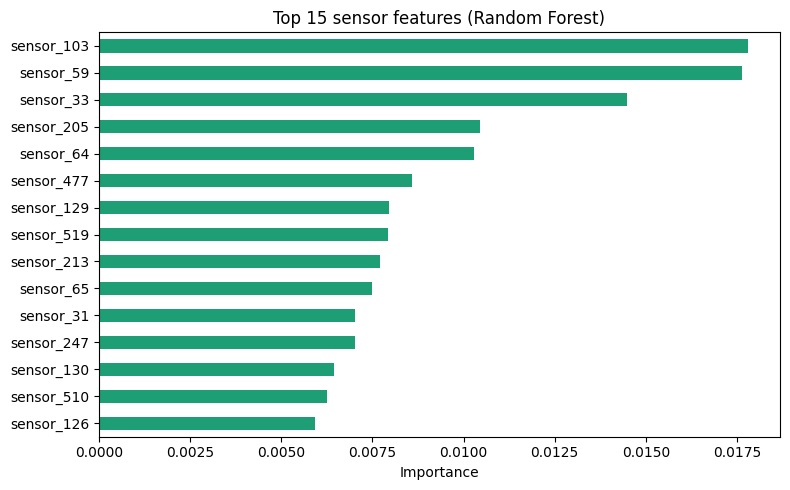

In [24]:
fig, ax = plt.subplots(figsize=(8, 5))
top_features.sort_values().plot.barh(ax=ax, color='#1D9E75')
ax.set_xlabel('Importance')
ax.set_title('Top 15 sensor features (Random Forest)')
plt.tight_layout()
plt.show()

## 7. Model 3 — LSTM Autoencoder (PyTorch)

Train on **pass-only** data. At inference, high reconstruction error signals a  
potential fault. This approach mirrors real manufacturing, where we have abundant  
normal data but rare failure examples.

Since SECOM features aren't inherently sequential, we reshape each sample into  
a (seq_len, feature_dim) tensor — treating sensor groups as pseudo-timesteps.  
This lets the LSTM learn cross-sensor dependencies.

In [25]:
# ── Reshape for LSTM: (batch, seq_len, features) ──
# We chunk 446 features into seq_len steps of feature_dim each
# 446 = 446 features → pad to 448 so we get 14 steps × 32 features
SEQ_LEN = 14
FEAT_DIM = 32
PAD_TO = SEQ_LEN * FEAT_DIM  # 448

def prepare_sequences(X_scaled):
    """Pad to 448 features and reshape to (n, 14, 32)."""
    n_samples, n_features = X_scaled.shape
    padded = np.zeros((n_samples, PAD_TO))
    padded[:, :n_features] = X_scaled
    return padded.reshape(n_samples, SEQ_LEN, FEAT_DIM)

# Train on pass-only samples
X_train_pass = X_train_sc[y_train == 0]
X_train_seq = prepare_sequences(X_train_pass)
X_test_seq = prepare_sequences(X_test_sc)

print(f'LSTM training set (pass-only): {X_train_seq.shape}')
print(f'LSTM test set (all):           {X_test_seq.shape}')

LSTM training set (pass-only): (1170, 14, 32)
LSTM test set (all):           (314, 14, 32)


### LSTM Autoencoder architecture

In [26]:
class LSTMAutoencoder(nn.Module):
    def __init__(self, feat_dim=32, hidden_dim=64, latent_dim=16, n_layers=1):
        super().__init__()
        self.feat_dim = feat_dim
        self.hidden_dim = hidden_dim
        self.n_layers = n_layers
        
        # Encoder
        self.encoder = nn.LSTM(
            input_size=feat_dim, hidden_size=hidden_dim,
            num_layers=n_layers, batch_first=True
        )
        self.enc_to_latent = nn.Linear(hidden_dim, latent_dim)
        
        # Decoder
        self.latent_to_dec = nn.Linear(latent_dim, hidden_dim)
        self.decoder = nn.LSTM(
            input_size=hidden_dim, hidden_size=hidden_dim,
            num_layers=n_layers, batch_first=True
        )
        self.output_layer = nn.Linear(hidden_dim, feat_dim)
    
    def forward(self, x):
        batch_size, seq_len, _ = x.shape
        
        # Encode: use final hidden state
        _, (h_n, _) = self.encoder(x)
        latent = self.enc_to_latent(h_n[-1])  # (batch, latent_dim)
        
        # Decode: repeat latent across timesteps
        dec_input = self.latent_to_dec(latent)  # (batch, hidden_dim)
        dec_input = dec_input.unsqueeze(1).repeat(1, seq_len, 1)  # (batch, seq_len, hidden_dim)
        dec_output, _ = self.decoder(dec_input)
        reconstruction = self.output_layer(dec_output)  # (batch, seq_len, feat_dim)
        
        return reconstruction

# Verify architecture
model = LSTMAutoencoder(feat_dim=FEAT_DIM, hidden_dim=64, latent_dim=16)
dummy = torch.randn(2, SEQ_LEN, FEAT_DIM)
out = model(dummy)
print(f'Input shape:  {dummy.shape}')
print(f'Output shape: {out.shape}')
print(f'Parameters:   {sum(p.numel() for p in model.parameters()):,}')

Input shape:  torch.Size([2, 14, 32])
Output shape: torch.Size([2, 14, 32])
Parameters:   62,576


### Training loop

Device: cpu
Epoch  10/50 | Loss: 0.931093
Epoch  20/50 | Loss: 0.908910
Epoch  30/50 | Loss: 0.894055
Epoch  40/50 | Loss: 0.886624
Epoch  50/50 | Loss: 0.876108

Reconstruction error threshold (95th pctl): 1.634112

--- LSTM Autoencoder ---
ROC-AUC: 0.5833  |  PR-AUC: 0.1024
              precision    recall  f1-score   support

        Pass       0.94      0.95      0.94       293
        Fail       0.12      0.10      0.11        21

    accuracy                           0.89       314
   macro avg       0.53      0.52      0.53       314
weighted avg       0.88      0.89      0.89       314



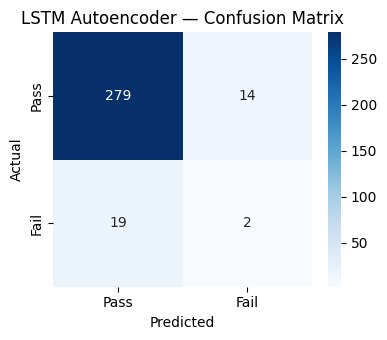

2026/03/30 10:52:33 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/30 10:52:33 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.



MLflow run ID: ead26e6dd41c448eb9480e7bf9edfd4a


In [27]:
# ── Hyperparameters ──
HIDDEN_DIM = 64
LATENT_DIM = 16
BATCH_SIZE = 64
EPOCHS = 50
LR = 1e-3

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

with mlflow.start_run(run_name='lstm_autoencoder'):
    # ── Log params ──
    lstm_params = {
        'hidden_dim': HIDDEN_DIM,
        'latent_dim': LATENT_DIM,
        'seq_len': SEQ_LEN,
        'feat_dim': FEAT_DIM,
        'batch_size': BATCH_SIZE,
        'epochs': EPOCHS,
        'learning_rate': LR,
        'model_type': 'autoencoder',
        'training_data': 'pass_only',
    }
    mlflow.log_params(lstm_params)
    
    # ── Data loaders ──
    train_tensor = torch.FloatTensor(X_train_seq)
    train_loader = DataLoader(
        TensorDataset(train_tensor, train_tensor),
        batch_size=BATCH_SIZE, shuffle=True
    )
    
    # ── Model, loss, optimizer ──
    model = LSTMAutoencoder(
        feat_dim=FEAT_DIM, hidden_dim=HIDDEN_DIM, latent_dim=LATENT_DIM
    ).to(device)
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=LR)
    
    # ── Train ──
    train_losses = []
    for epoch in range(EPOCHS):
        model.train()
        epoch_loss = 0
        for batch_x, _ in train_loader:
            batch_x = batch_x.to(device)
            reconstruction = model(batch_x)
            loss = criterion(reconstruction, batch_x)
            
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item() * batch_x.size(0)
        
        epoch_loss /= len(train_loader.dataset)
        train_losses.append(epoch_loss)
        mlflow.log_metric('train_loss', epoch_loss, step=epoch)
        
        if (epoch + 1) % 10 == 0:
            print(f'Epoch {epoch+1:3d}/{EPOCHS} | Loss: {epoch_loss:.6f}')
    
    # ── Compute reconstruction error on test set ──
    model.eval()
    test_tensor = torch.FloatTensor(X_test_seq).to(device)
    with torch.no_grad():
        recon = model(test_tensor)
        lstm_scores = ((test_tensor - recon) ** 2).mean(dim=(1, 2)).cpu().numpy()
    
    # ── Threshold: 95th percentile of training reconstruction error ──
    model.eval()
    with torch.no_grad():
        train_recon = model(train_tensor.to(device))
        train_errors = ((train_tensor.to(device) - train_recon) ** 2).mean(dim=(1, 2)).cpu().numpy()
    threshold_95 = np.percentile(train_errors, 95)
    print(f'\nReconstruction error threshold (95th pctl): {threshold_95:.6f}')
    
    lstm_preds = (lstm_scores > threshold_95).astype(int)
    mlflow.log_param('anomaly_threshold_95pctl', round(float(threshold_95), 6))
    
    # ── Evaluate ──
    lstm_metrics, lstm_pr_prec, lstm_pr_rec, lstm_cm_fig = evaluate_model(
        y_test, lstm_preds, lstm_scores, 'LSTM Autoencoder'
    )
    mlflow.log_metrics(lstm_metrics)
    mlflow.log_figure(lstm_cm_fig, 'confusion_matrix.png')
    plt.show()
    
    # ── Log model ──
    mlflow.pytorch.log_model(model, 'model')
    
    lstm_run_id = mlflow.active_run().info.run_id
    print(f'\nMLflow run ID: {lstm_run_id}')

### Training loss curve

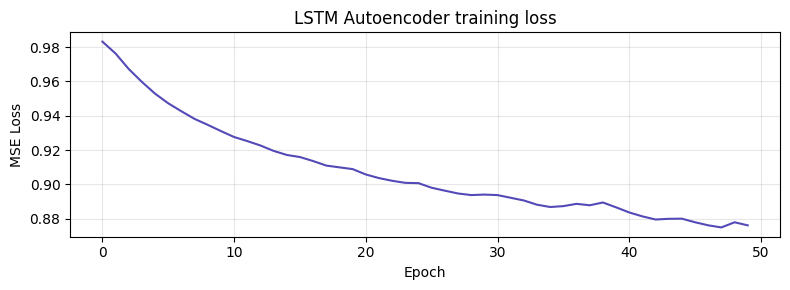

In [28]:
fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(train_losses, color='#534AB7', linewidth=1.5)
ax.set_xlabel('Epoch')
ax.set_ylabel('MSE Loss')
ax.set_title('LSTM Autoencoder training loss')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 8. Model comparison

Side-by-side metrics, PR curves, and reconstruction error distribution.

In [29]:
# ── Summary table ──
summary = pd.DataFrame({
    'Model': ['Isolation Forest', 'Random Forest (t=tuned)', 'LSTM Autoencoder'],
    'Type': ['Unsupervised', 'Supervised', 'Autoencoder'],
    'ROC-AUC': [iso_metrics['roc_auc'], rf_metrics['roc_auc'], lstm_metrics['roc_auc']],
    'PR-AUC': [iso_metrics['pr_auc'], rf_metrics['pr_auc'], lstm_metrics['pr_auc']],
    'Fail Recall': [iso_metrics['fail_recall'], rf_metrics['fail_recall'], lstm_metrics['fail_recall']],
    'Fail Precision': [iso_metrics['fail_precision'], rf_metrics['fail_precision'], lstm_metrics['fail_precision']],
    'Fail F1': [iso_metrics['fail_f1'], rf_metrics['fail_f1'], lstm_metrics['fail_f1']],
})
print(summary.to_string(index=False))

                  Model         Type  ROC-AUC   PR-AUC  Fail Recall  Fail Precision  Fail F1
       Isolation Forest Unsupervised 0.573216 0.152877     0.190476           0.200 0.195122
Random Forest (t=tuned)   Supervised 0.792784 0.208431     0.333333           0.350 0.341463
       LSTM Autoencoder  Autoencoder 0.583293 0.102425     0.095238           0.125 0.108108


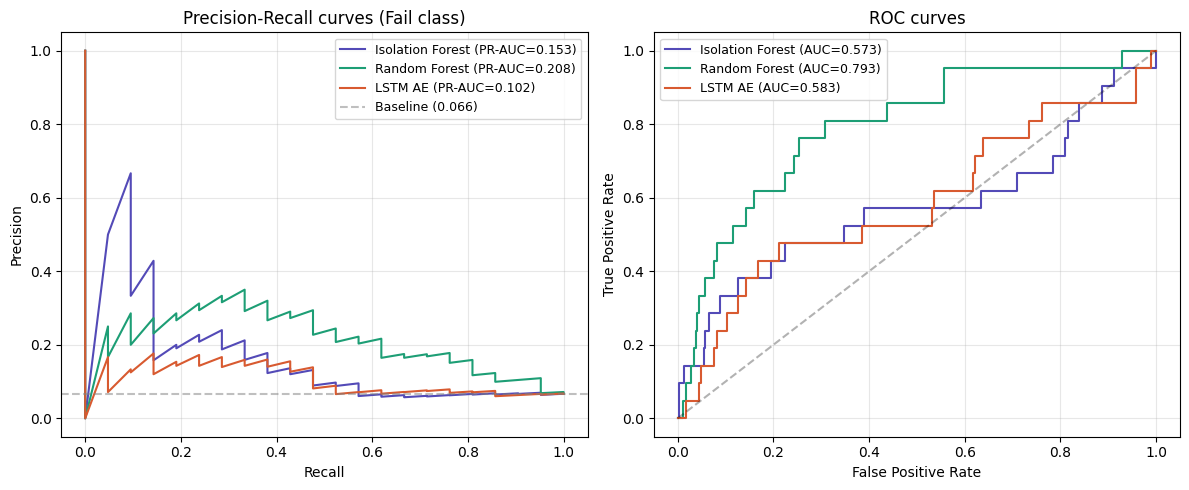

In [30]:
# ── PR curves ──
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# PR Curve
ax = axes[0]
ax.plot(iso_pr_rec, iso_pr_prec, label=f'Isolation Forest (PR-AUC={iso_metrics["pr_auc"]:.3f})', color='#534AB7', linewidth=1.5)
ax.plot(rf_pr_rec, rf_pr_prec, label=f'Random Forest (PR-AUC={rf_metrics["pr_auc"]:.3f})', color='#1D9E75', linewidth=1.5)
ax.plot(lstm_pr_rec, lstm_pr_prec, label=f'LSTM AE (PR-AUC={lstm_metrics["pr_auc"]:.3f})', color='#D85A30', linewidth=1.5)
ax.axhline(y=y.mean(), color='gray', linestyle='--', alpha=0.5, label=f'Baseline ({y.mean():.3f})')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Precision-Recall curves (Fail class)')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# ROC Curve
ax = axes[1]
for name, scores, color in [
    ('Isolation Forest', iso_scores, '#534AB7'),
    ('Random Forest', rf_proba, '#1D9E75'),
    ('LSTM AE', lstm_scores, '#D85A30'),
]:
    fpr, tpr, _ = roc_curve(y_test, scores)
    roc_val = roc_auc_score(y_test, scores)
    ax.plot(fpr, tpr, label=f'{name} (AUC={roc_val:.3f})', color=color, linewidth=1.5)
ax.plot([0, 1], [0, 1], 'k--', alpha=0.3)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC curves')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### LSTM reconstruction error distribution

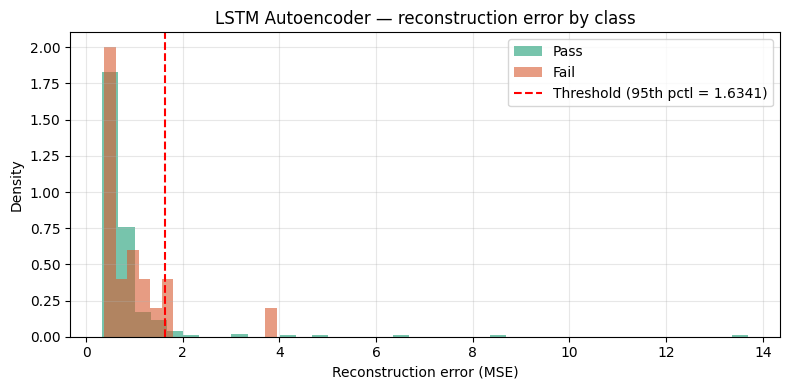

In [31]:
fig, ax = plt.subplots(figsize=(8, 4))

pass_scores = lstm_scores[y_test == 0]
fail_scores = lstm_scores[y_test == 1]

ax.hist(pass_scores, bins=40, alpha=0.6, label='Pass', color='#1D9E75', density=True)
ax.hist(fail_scores, bins=15, alpha=0.6, label='Fail', color='#D85A30', density=True)
ax.axvline(threshold_95, color='red', linestyle='--', label=f'Threshold (95th pctl = {threshold_95:.4f})')
ax.set_xlabel('Reconstruction error (MSE)')
ax.set_ylabel('Density')
ax.set_title('LSTM Autoencoder — reconstruction error by class')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 9. Review MLflow runs

Launch the MLflow UI to compare runs interactively:
```bash
mlflow ui --backend-store-uri mlruns
```
Then open `http://localhost:5000` in your browser.

In [32]:
# Quick programmatic check
runs = mlflow.search_runs(experiment_names=[EXPERIMENT_NAME])
print(runs[['run_id', 'params.model_type', 'metrics.roc_auc', 'metrics.fail_f1']].to_string(index=False))

                          run_id params.model_type  metrics.roc_auc  metrics.fail_f1
ead26e6dd41c448eb9480e7bf9edfd4a       autoencoder         0.583293         0.108108
6357a161289c402eac8549b0bafda09a        supervised         0.792784         0.341463
38329419543d47259e78d3fa4cfc5566      unsupervised         0.573216         0.195122
9d6d2ead68dc4a3fa786f613b56d914a       autoencoder         0.583293         0.108108
f94ad575283840cbbbea023675dc60df        supervised         0.792784         0.341463
89f20e94ed434593b254fdac4421a58f      unsupervised         0.573216         0.195122


## Key takeaways

1. **Threshold tuning is essential** with 14:1 imbalance — the Random Forest's default 0.5  
   threshold predicts zero fails, but at the tuned threshold it achieves meaningful recall.  
2. **Isolation Forest** provides a quick unsupervised baseline but struggles with 446 features.  
3. **LSTM Autoencoder** learns normal operating patterns and flags deviations via  
   reconstruction error — this mirrors how real semiconductor fabs detect process drift.  
4. **MLflow tracking** makes it easy to compare runs and reproduce results.  

**Next steps**: SHAP explainability on the Random Forest to surface which sensors  
drive fault predictions, then a FastAPI inference endpoint.